# 0. Data Preprocessing & Feature Engineering Playground

In this notebook, we transform the raw, event-driven Online Retail II dataset into a robust, ML-ready temporal panel. 

To ensure our codebase remains scalable, testable, and production-ready, the core data manipulation logic has been decoupled and abstracted into modular Python tools within the `src/tools/` directory. This notebook serves as an **interactive playground** to visualize the pipeline's execution flow, validate transformations, and tune hyperparameters before orchestrating the final dataset generation via the headless `process_data.py` script.

### Pipeline Overview:
1. **Imports & Loading**: Ingesting raw Excel files through a centralized data loader.
2. **Data Cleansing & Separation**: Isolating true demand signals by filtering anomalies and separating valid sales from returns.
3. **Weekly Aggregation & Zero-Filling**: Converting discrete transactional events into a continuous temporal panel, explicitly defining periods of zero demand.
4. **Advanced Feature Engineering**: Injecting exogenous signals (Calendar events, UK Holidays), auto-regressive lags, and pricing metrics.
5. **Semantic Embeddings**: Leveraging the Google Gemini LLM API to map product text descriptions into a 768-dimensional latent space.
6. **Temporal Train/Test Split**: Enforcing strict chronological boundaries to prevent downstream data leakage.
7. **Static Profiling**: Calculating intrinsic SKU behavior (Demand Intermittency and Commercial Value) exclusively on the training window.
8. **Triple Clustering Architecture**: Segmenting the product portfolio using HDBSCAN, K-Means (Behavioral), and Jenks Natural Breaks (Volume).
9. **Final Integration & Export**: Merging the engineered ecosystem into a highly optimized Parquet format for predictive modeling (LightGBM/DeepAR).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

# Ensure we can seamlessly import all modular functions from the src directory
PROJECT_ROOT = os.path.abspath("..")
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# Import our specialized pipeline tools
# Import our specialized pipeline tools via the centralized interface
from src.tools import (
    load_raw_data,
    clean_and_split_transactions,
    trim_inactive_periods,
    aggregate_weekly_sku,
    add_temporal_features,
    add_historical_features,
    add_pricing_features,
    calculate_demand_profile,
    calculate_commercial_profile,
    create_seasonal_profile_clusters,
    create_volume_clusters,
    create_semantic_clusters,
    embed_sku_descriptions
)

print("Setup complete. Environment mapped and modular tools loaded.")

Setup complete. Environment mapped and modular tools loaded.


## 1. Data Loading & Inspection

Raw ERP/system exports are inherently noisy and memory-intensive. Before initiating any mathematical transformations, we must establish a clean baseline. Our centralized `load_raw_data` tool handles the heavy lifting: reading the legacy `.xlsx` format, coercing datatypes into memory-efficient pandas objects, and standardizing column nomenclature to ensure downstream compatibility.

In [2]:
print("Loading raw retail data (this might take 30 seconds due to Excel format)...")
input_path = os.path.join(PROJECT_ROOT, "data/raw", "online_retail_II.xlsx")
raw_df = load_raw_data(input_path)

print(f"Data loaded. Shape: {raw_df.shape}")

raw_df

Loading raw retail data (this might take 30 seconds due to Excel format)...
Data loaded. Shape: (1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


## 2. Cleansing & Sales/Returns Bifurcation

In retail forecasting, blending sales and returns into a single "net quantity" stream distorts the true consumer demand signal. A return is a reverse logistics event, not a negative demand event.

Furthermore, traditional Time Series models (like ARIMA) and error metrics (like MAPE) degrade or fail when encountering negative target variables. Here, we aggressively filter out system anomalies, administrative codes, and separate valid sales (strictly positive quantities) from returns/cancellations. This guarantees a clean, zero-bound target variable for our models.

In [3]:
print("Separating valid sales from returns and cleaning text...")
sales_df, returns_df = clean_and_split_transactions(raw_df, verbose=True)

sales_df

Separating valid sales from returns and cleaning text...
Removed 4382 rows with missing values.
Changed Invoice and StockCode to string type.
Stripping whitespace from 213035 rows.
Removing 7399 rows with invalid StockCodes.
Removing 487 rows with operational notes.
Removing 1307 rows with negative or zero prices.
Created 'Week' column aligned to Monday.
Identified 18176 cancellations and 18176 negative quantities.
Created valid_sales dataframe with 1035620 rows.
Created valid_returns dataframe with 18176 rows.


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Week,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,2009-11-30,83.40
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009-11-30,81.00
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009-11-30,81.00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,2009-11-30,100.80
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,2009-11-30,30.00
...,...,...,...,...,...,...,...,...,...,...
1067365,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,2011-12-05,10.20
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,2011-12-05,12.60
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,2011-12-05,16.60
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,2011-12-05,16.60


In [4]:
returns_df

,StockCode,Week,Quantity,Customer ID,Country
178,22087,2009-11-30,12,16321.0,Australia
179,85206A,2009-11-30,6,16321.0,Australia
180,21895,2009-11-30,4,16321.0,Australia
181,21896,2009-11-30,6,16321.0,Australia
182,22083,2009-11-30,12,16321.0,Australia
...,...,...,...,...,...
1065909,22178,2011-12-05,12,14397.0,United Kingdom
1065910,23144,2011-12-05,11,14397.0,United Kingdom
1067176,21258,2011-12-05,5,15311.0,United Kingdom
1067177,84978,2011-12-05,1,17315.0,United Kingdom


## 3. Weekly Aggregation & Zero-Filling (Panel Construction)

Raw data records events only when a transaction occurs. However, predictive models require a continuous timeframe to learn patterns effectively. If a product records zero sales in Week 3, that absence of data is a crucial signal.

We transition from a transactional ledger to a **multi-variate Time Series Panel**. This step aggregates quantities to a weekly frequency and applies continuous zero-filling across the active lifecycle of each SKU, ensuring our algorithms learn both *when* a product sells and *when it does not*.

In [5]:
print("Aggregating transactions into weekly buckets per SKU (with continuous zero-filling)...")
weekly_sales = aggregate_weekly_sku(sales_df)

print(f"Weekly Panel Rows: {len(weekly_sales):,}")
weekly_sales

Aggregating transactions into weekly buckets per SKU (with continuous zero-filling)...
Weekly Panel Rows: 516,538


,StockCode,Week,Quantity,Revenue
0,10002,2009-11-30,141,119.85
1,10002,2009-12-07,24,21.25
2,10002,2009-12-14,37,32.30
3,10002,2009-12-21,14,12.75
4,10002,2009-12-28,0,0.00
...,...,...,...,...
516533,90214Z,2011-11-07,0,0.00
516534,90214Z,2011-11-14,0,0.00
516535,90214Z,2011-11-21,0,0.00
516536,90214Z,2011-11-28,0,0.00


## 4. Lifecycle Trimming (Leading Zeros & Delisted SKUs)

In retail forecasting, understanding a product's true active lifecycle is essential. If a product was newly launched in mid-2010, feeding the model "zero demand" for the entirety of 2009 introduces false intermittency and heavily skews the historical averages. 

Similarly, products that have recorded strictly zero sales in the weeks leading up to our validation window have likely been delisted, discontinued, or permanently stocked out. By systematically trimming pre-launch periods and filtering out "dead" inventory, we dramatically reduce computational noise and ensure our Machine Learning models allocate their capacity strictly to the active portfolio.

In [6]:
print("Trimming leading zeros (pre-launch) and removing discontinued products...")

# Apply the lifecycle trimming tool to isolate active periods
weekly_sales = trim_inactive_periods(weekly_sales)

print(f"Active Panel Rows after lifecycle trimming: {len(weekly_sales):,}")
weekly_sales

Trimming leading zeros (pre-launch) and removing discontinued products...
Trimming leading zeros (finding actual launch date for each SKU)...
Trimmed pre-launch periods. Remaining rows: 432490
Removing inactive SKUs (0 sales in the 4 weeks prior to test cutoff)...
Detected 2063 inactive SKUs in the 4 weeks before cutoff.
Removed inactive products. Remaining rows: 222713
Active Panel Rows after lifecycle trimming: 222,713


,StockCode,Week,Quantity,Revenue
212,10080,2009-11-30,4,3.40
213,10080,2009-12-07,0,0.00
214,10080,2009-12-14,0,0.00
215,10080,2009-12-21,0,0.00
216,10080,2009-12-28,0,0.00
...,...,...,...,...
515897,90214S,2011-11-07,0,0.00
515898,90214S,2011-11-14,12,15.00
515899,90214S,2011-11-21,0,0.00
515900,90214S,2011-11-28,0,0.00


## 5. Exogenous Signals & Feature Engineering

To empower tree-based models (like LightGBM) to forecast accurately, we must enrich the raw time series with contextual features. We inject three distinct layers of intelligence:
1. **Temporal Context**: Calendar primitives (Month, Quarter) and regional anomalies (UK Bank Holidays) to capture recurring seasonality.
2. **Historical Lags & Rolling Metrics**: Auto-regressive features that provide the model with recent memory (e.g., "What were the sales 2 weeks ago?"). We also track rolling return rates to flag potentially defective batches.
3. **Pricing & Promotions**: Tracking the median static price and flagging promotional discounts to help the model learn the *price elasticity* of demand.

In [7]:
print("Adding temporal (calendar) features...")
weekly_sales = add_temporal_features(weekly_sales)

print("Adding historical (lags & rolling return rates) features...")
weekly_sales = add_historical_features(weekly_sales, returns_df)

print("Adding pricing metrics (median price & promotional flags)...")
weekly_sales = add_pricing_features(weekly_sales, sales_df)

print("Feature Engineering complete!")
weekly_sales

Adding temporal (calendar) features...
Adding historical (lags & rolling return rates) features...
Adding pricing metrics (median price & promotional flags)...
Feature Engineering complete!


,StockCode,Week,Quantity,Revenue,week_of_year,month,quarter,year,sin_woy,cos_woy,...,lag_4,lag_13,lag_52,rmean_4,rstd_4,rmean_13,rstd_13,price_weekly,price_percent_change,is_on_promotion
0,10080,2009-11-30,4,3.40,49,11,4,2009,-3.546049e-01,0.935016,...,NaN,NaN,NaN,NaN,0.000000,NaN,0.000000,0.85,0.0,0
1,10080,2009-12-07,0,0.00,50,12,4,2009,-2.393157e-01,0.970942,...,NaN,NaN,NaN,4.000000,0.000000,4.000000,0.000000,NaN,0.0,0
2,10080,2009-12-14,0,0.00,51,12,4,2009,-1.205367e-01,0.992709,...,NaN,NaN,NaN,2.000000,2.828427,2.000000,2.828427,NaN,0.0,0
3,10080,2009-12-21,0,0.00,52,12,4,2009,6.432491e-16,1.000000,...,NaN,NaN,NaN,1.333333,2.309401,1.333333,2.309401,NaN,0.0,0
4,10080,2009-12-28,0,0.00,53,12,4,2009,1.205367e-01,0.992709,...,4.0,NaN,NaN,1.000000,2.000000,1.000000,2.000000,NaN,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
222708,90214S,2011-11-07,0,0.00,45,11,4,2011,-7.485107e-01,0.663123,...,0.0,0.0,3.0,0.500000,0.577351,0.923077,0.954074,NaN,0.0,0
222709,90214S,2011-11-14,12,15.00,46,11,4,2011,-6.631227e-01,0.748511,...,1.0,0.0,4.0,0.500000,0.577351,0.923077,0.954074,1.25,0.0,0
222710,90214S,2011-11-21,0,0.00,47,11,4,2011,-5.680647e-01,0.822984,...,0.0,0.0,5.0,3.250000,5.852350,1.846154,3.184498,NaN,0.0,0
222711,90214S,2011-11-28,0,0.00,48,11,4,2011,-4.647232e-01,0.885456,...,1.0,3.0,6.0,3.250000,5.852350,1.846154,3.184498,NaN,0.0,0


## 6. Semantic Embeddings via LLM

A major challenge in retail forecasting is the "Cold-Start Problem" and high SKU churn. How does a model forecast a newly launched "RED CERAMIC MUG" with no historical data?

By utilizing the Google Gemini API, we translate textual product descriptions into 768-dimensional mathematical vectors. This maps products into a latent semantic space, allowing the ML model to infer that a "RED MUG" behaves similarly to a "BLUE MUG". *Note: Embeddings are computationally expensive, so results are saved to a local `.parquet` cache to minimize latency and API billing.*

In [8]:
print("Generating or loading semantic embeddings from product descriptions...")
embeddings_cache_path = os.path.join(PROJECT_ROOT, "data", "embeddings_cache.parquet")
embeddings_df = embed_sku_descriptions(sales_df, cache_path=embeddings_cache_path, verbose=True)

print(f"Total Unique Products Embedded: {len(embeddings_df):,}")
embeddings_df[['StockCode', 'desc_canonical', 'embedding']]

Generating or loading semantic embeddings from product descriptions...
Loading cached embeddings from /Users/federicogiorgi/Library/CloudStorage/OneDrive-Personal/Documenti/GitHub/forecasting-retail/data/embeddings_cache.parquet...
Total Unique Products Embedded: 4,873


,StockCode,desc_canonical,embedding
0,10002,INFLATABLE POLITICAL GLOBE,"[-0.023739288, 0.01494101, -0.00474035, -0.010..."
1,10002R,ROBOT PENCIL SHARPNER,"[-0.026207298, -0.0125879515, -0.03767904, -0...."
2,10080,GROOVY CACTUS INFLATABLE,"[-0.012332139, 0.07398322, 0.0060417657, -0.00..."
3,10109,BENDY COLOUR PENCILS,"[-0.009220765, -0.0043453868, 0.008214232, -0...."
4,10120,DOGGY RUBBER,"[-0.0008220375, 0.001956208, -0.007456975, -0...."
...,...,...,...
4868,90214U,"LETTER ""U"" BLING KEY RING","[-0.09458911, 0.014469348, 0.022742419, 0.0018..."
4869,90214V,"LETTER ""V"" BLING KEY RING","[-0.08106986, 0.020798966, 0.019458953, -0.029..."
4870,90214W,"LETTER ""W"" BLING KEY RING","[-0.09305075, 0.04100852, 0.019039465, -0.0359..."
4871,90214Y,"LETTER ""Y"" BLING KEY RING","[-0.08345271, 0.026875347, 0.0064515867, -0.01..."


## 7. Temporal Train/Test Split (Data Leakage Prevention)

Before computing any global aggregate metrics or clusters (e.g., identifying a product's seasonal profile or total volume tier), we must strictly segment our timeline. 

If we calculate a product's total yearly volume using the entire dataset, we inadvertently bleed future information (2011 data) into the features used to train the model on past data (2010). This creates severe **Data Leakage**, resulting in overly optimistic backtesting metrics that will fail in production. We isolate the training data to simulate a true production cutoff.

In [9]:
print("Splitting data to calculate clusters using ONLY training data...")
# The dataset ends in Dec 2011. We use the last ~3 months for the test set.
from src.config import TEST_CUTOFF_DT

weekly_sales_train = weekly_sales[weekly_sales["Week"] < TEST_CUTOFF_DT]
sales_df_train = sales_df[sales_df["InvoiceDate"] < TEST_CUTOFF_DT]

print(f"Training Rows Cutoff Complete.")

Splitting data to calculate clusters using ONLY training data...
Training Rows Cutoff Complete.


In [10]:
sales_df_train

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Week,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,2009-11-30,83.40
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009-11-30,81.00
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009-11-30,81.00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,2009-11-30,100.80
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,2009-11-30,30.00
...,...,...,...,...,...,...,...,...,...,...
846150,565067,22645,CERAMIC HEART FAIRY CAKE MONEY BANK,2,2011-08-31 17:16:00,1.45,15856.0,United Kingdom,2011-08-29,2.90
846151,565067,22637,PIGGY BANK RETROSPOT,2,2011-08-31 17:16:00,2.55,15856.0,United Kingdom,2011-08-29,5.10
846152,565067,22646,CERAMIC STRAWBERRY CAKE MONEY BANK,2,2011-08-31 17:16:00,1.45,15856.0,United Kingdom,2011-08-29,2.90
846153,565067,22741,FUNKY DIVA PEN,48,2011-08-31 17:16:00,0.85,15856.0,United Kingdom,2011-08-29,40.80


## 8. Static Profiling (Demand & Commercial Profiles)

Before attempting unsupervised clustering, we must extract meaningful metadata for every single SKU based *exclusively* on the isolated training window. 

We generate two comprehensive profiles:
1. **Demand Profile:** Analyzes the chronological behavior of the SKU. It calculates metrics like Inter-Purchase Time (days between sales), standard deviation of demand, and intermittency ratios (identifying "Smooth" vs. "Lumpy" demand).
2. **Commercial Profile:** Analyzes the financial impact and pricing stability. It computes the total revenue contribution, average basket penetration, and price volatility across the training period.

In [11]:
print("Building static SKU profiles (Demand & Commercial) on Train set...")
demand_df = calculate_demand_profile(weekly_sales_train)
commercial_df = calculate_commercial_profile(sales_df_train)
demand_df

Building static SKU profiles (Demand & Commercial) on Train set...


,StockCode,ADI,CV2,demand_class,share_zero_weeks
0,10080,8.363636,1.309806,lumpy,0.880435
1,10120,2.705882,1.314653,lumpy,0.630435
2,10125,1.483871,0.899712,lumpy,0.326087
3,10133,1.260274,1.528233,erratic,0.206522
4,10135,1.150000,3.965517,erratic,0.130435
...,...,...,...,...,...
2552,90214L,2.190476,1.002228,lumpy,0.543478
2553,90214M,2.486486,1.016519,lumpy,0.597826
2554,90214N,2.875000,1.227358,lumpy,0.652174
2555,90214R,2.705882,0.901875,lumpy,0.630435


In [12]:
commercial_df

,StockCode,price_median,mean_basket_size,n_unique_customers,country_uk_share
0,10002,0.85,22.598465,164,0.836317
1,10002R,5.17,1.333333,0,1.000000
2,10080,0.39,10.533333,12,1.000000
3,10109,0.42,4.000000,1,1.000000
4,10120,0.21,9.758065,42,0.967742
...,...,...,...,...,...
4595,90214U,1.25,1.000000,1,1.000000
4596,90214V,0.85,1.125000,6,1.000000
4597,90214W,0.85,1.000000,2,1.000000
4598,90214Y,0.85,1.000000,2,1.000000


## 9. Triple Clustering Architecture

Relying on a single segmentation strategy is insufficient for a diverse retail portfolio. To provide our Machine Learning models with robust categorical context, we apply a multi-dimensional unsupervised learning approach:
1. **Behavioral Clustering (Time-Series Shape)**: Groups SKUs by their chronological sales distribution across the year.
2. **Semantic Clustering (Product Identity)**: Groups SKUs by their physical/functional similarities using LLM embeddings.
3. **Volume Clustering (Financial Scale)**: Groups SKUs by their absolute magnitude of sales (Fast Movers vs. Long Tail).

### 8.1 Behavioral Clustering (Seasonal Profiles)
We seek to identify the intrinsic "shape" of demand (e.g., Summer Peak, Christmas Spike, Flat Baseline) regardless of the absolute volume sold. 
To achieve this, we extract the 52-week quantity curves, strictly normalize them using a `MinMaxScaler` (so all curves span 0 to 1), and use the Elbow Method to evaluate the optimal variance-reduction for K-Means clustering.

Extracting 52-week seasonal profiles from training data...
Creating average weekly seasonal profiles...
Normalizing profiles using transpose logic (MinMaxScaler)...
Calculating inertia for K-Means Elbow Method...


/opt/anaconda3/envs/columbia/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/columbia/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/columbia/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/columbia/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:243: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/anaconda3/envs/columbia/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:243: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/anaconda3/envs/columbia/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:243: RuntimeWarning: invalid value encountered in matmul
  current_pot = closest_

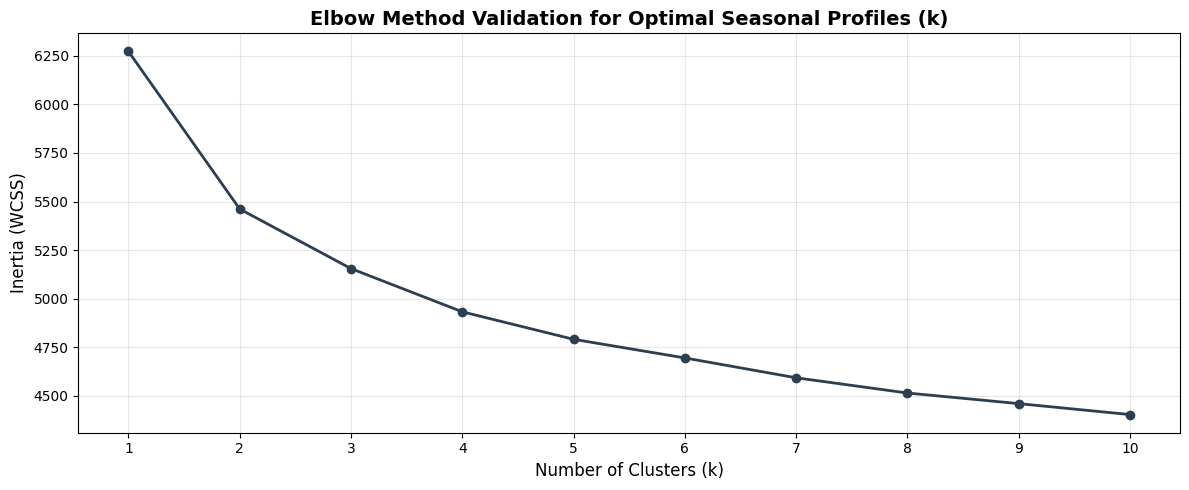

In [13]:
print("Extracting 52-week seasonal profiles from training data...")
df_train = weekly_sales_train.copy()
df_train["week_of_year"] = df_train["Week"].dt.isocalendar().week

print("Creating average weekly seasonal profiles...")
profiles = df_train.groupby(["StockCode", "week_of_year"], observed=True)["Quantity"].mean().unstack().fillna(0)

# Ensure all 52 weeks are mapped
profiles = profiles.reindex(columns=range(1, 53), fill_value=0)

print("Normalizing profiles using transpose logic (MinMaxScaler)...")
scaler = MinMaxScaler()
profiles_scaled = scaler.fit_transform(profiles.T).T
profiles_scaled = np.ascontiguousarray(profiles_scaled)

inertia = []
K_range = range(1, 11)

print("Calculating inertia for K-Means Elbow Method...")
for k in K_range:
    model = KMeans(n_clusters=k, random_state=42, n_init="auto")
    model.fit(profiles_scaled)
    inertia.append(model.inertia_)

# Plot the Elbow Method
plt.figure(figsize=(12, 5))
plt.plot(K_range, inertia, marker='o', linestyle='-', color='#2c3e50', linewidth=2)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Inertia (WCSS)', fontsize=12)
plt.title('Elbow Method Validation for Optimal Seasonal Profiles (k)', fontsize=14, fontweight='bold')
plt.xticks(K_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Now we apply `k = 5` to extract and visualize the seasonal profiles.

Creating Behavioral Clusters (52-Week Seasonal Profiles)...
Calculating seasonal shape clusters (k=5) based on weekly data...
Executing final K-Means with k=5 clusters...


/opt/anaconda3/envs/columbia/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/columbia/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/columbia/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/columbia/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:243: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/anaconda3/envs/columbia/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:243: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/anaconda3/envs/columbia/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:243: RuntimeWarning: invalid value encountered in matmul
  current_pot = closest_

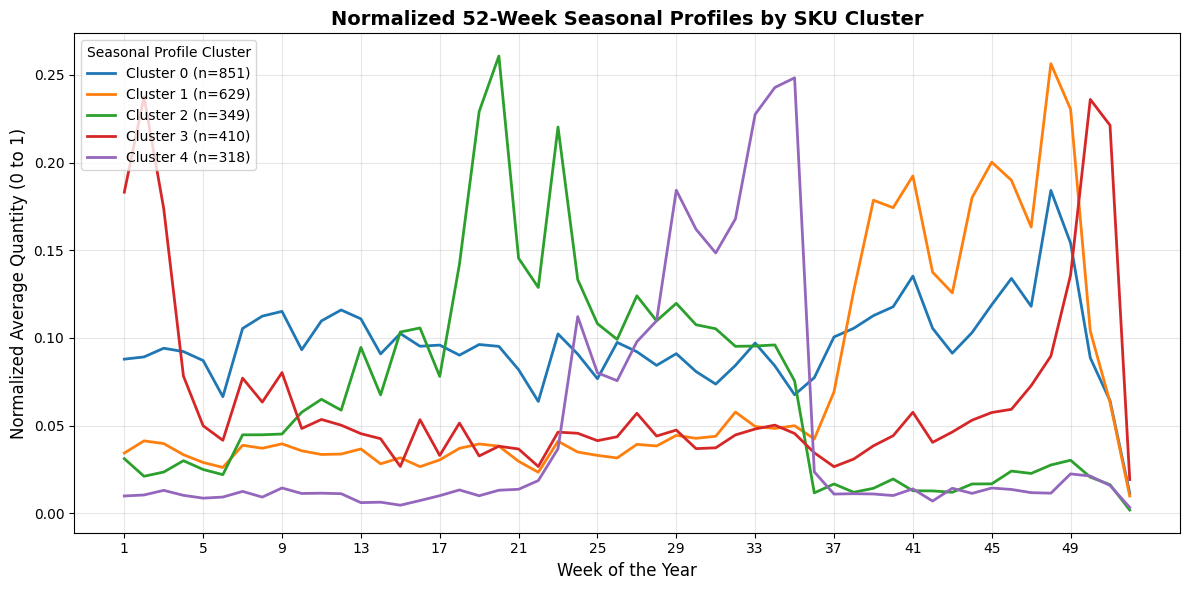

,StockCode,profile_cluster_id
0,10080,4
1,10120,1
2,10125,0
3,10133,4
4,10135,3
...,...,...
2552,90214L,1
2553,90214M,1
2554,90214N,1
2555,90214R,1


In [14]:
print("Creating Behavioral Clusters (52-Week Seasonal Profiles)...")
profile_clusters = create_seasonal_profile_clusters(
    weekly_aggregated_sales=weekly_sales_train, 
    n_clusters=5, 
    plot=True
)

profile_clusters

### 8.2 Semantic Clustering (Unsupervised Categorization)
Unlike modern e-commerce platforms, legacy retail datasets often lack clean hierarchical categories (e.g., "Home Decor > Kitchenware"). We solve this via Unsupervised NLP. By applying clustering algorithms over our Gemini 768-D embeddings, we automatically discover latent product families. We then utilize `TF-IDF` to extract the most salient keywords, algorithmically naming the clusters for human interpretability.

Creating Semantic Categories from Text Embeddings...


/opt/anaconda3/envs/columbia/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/columbia/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/columbia/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/columbia/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:243: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/anaconda3/envs/columbia/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:243: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/anaconda3/envs/columbia/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:243: RuntimeWarning: invalid value encountered in matmul
  current_pot = closest_

Reducing dimensions via UMAP for semantic visualization...


/opt/anaconda3/envs/columbia/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


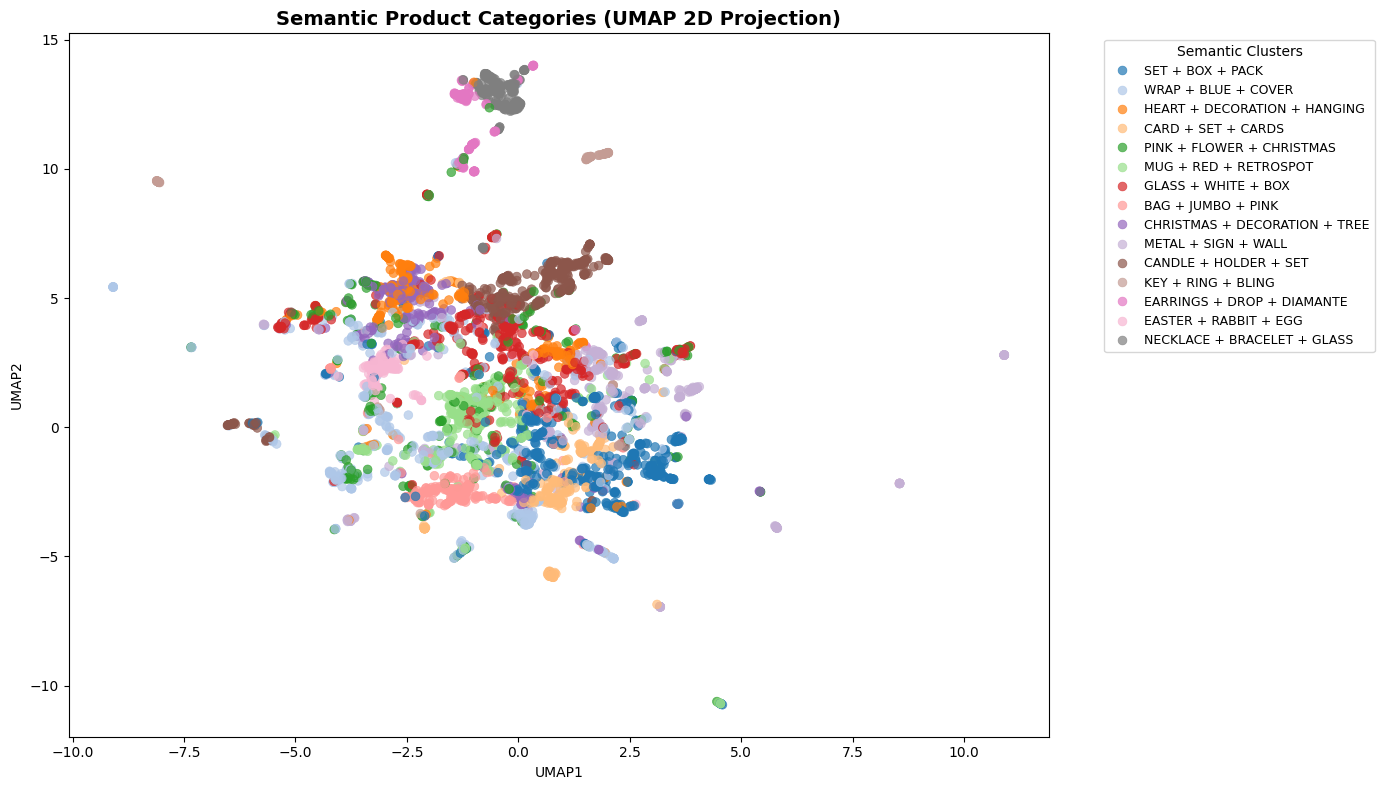

semantic_cluster_name
SET + BOX + PACK                 597
GLASS + WHITE + BOX              538
WRAP + BLUE + COVER              506
MUG + RED + RETROSPOT            427
CANDLE + HOLDER + SET            420
METAL + SIGN + WALL              397
PINK + FLOWER + CHRISTMAS        304
CHRISTMAS + DECORATION + TREE    302
HEART + DECORATION + HANGING     298
CARD + SET + CARDS               273
BAG + JUMBO + PINK               223
NECKLACE + BRACELET + GLASS      212
EASTER + RABBIT + EGG            159
EARRINGS + DROP + DIAMANTE       133
KEY + RING + BLING                84
Name: count, dtype: int64

In [15]:
print("Creating Semantic Categories from Text Embeddings...")
semantic_clusters = create_semantic_clusters(
    embeddings_df, 
    n_clusters=15, 
    plot=True
)

# Preview the auto-generated semantic names
semantic_clusters["semantic_cluster_name"].value_counts()

### 8.3 Volume Clustering (Jenks Natural Breaks)
Retail sales are rarely normally distributed; they suffer from extreme Pareto skew (the 80/20 rule). Traditional percentiles fail to capture the true mathematical "gaps" between blockbuster items and the long tail. We deploy Jenks Natural Breaks Optimization—an algorithm standard in spatial data analysis—to minimize intra-class variance and maximize inter-class variance, isolating true volume tiers.

Creating Volume Clusters (Jenks Natural Breaks) on Train set...


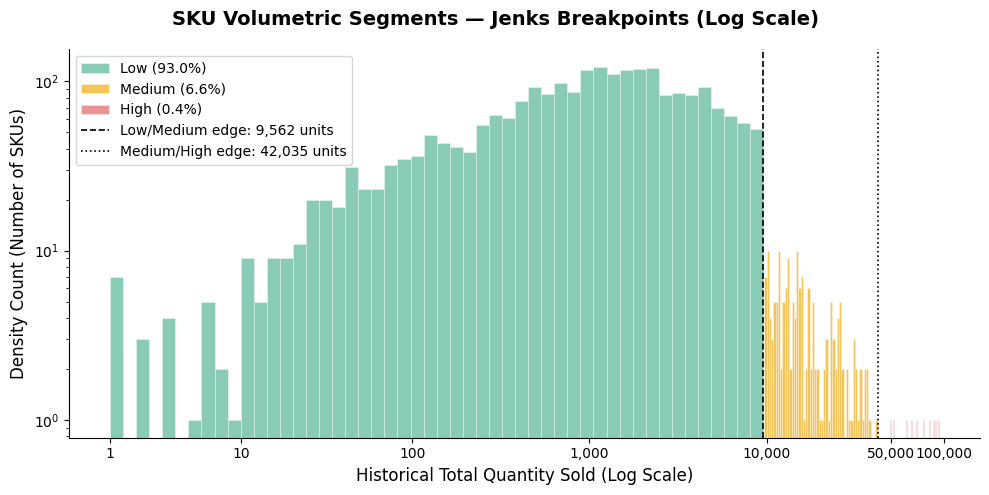

,StockCode,volume_tier
0,10080,Low
1,10120,Low
2,10125,Low
3,10133,Low
4,10135,Low
...,...,...
2552,90214L,Low
2553,90214M,Low
2554,90214N,Low
2555,90214R,Low


In [16]:
print("Creating Volume Clusters (Jenks Natural Breaks) on Train set...")
volume_clusters = create_volume_clusters(weekly_sales_train, n_tiers=3, plot=True)

volume_clusters

## 10. Final Integration & Parquet Export

In this final step, we broadcast our static cluster assignments and profiles (learned strictly from the training set) back onto the complete timeline via a Left Join strategy. 

We systematically drop anomalous SKUs that could not be clustered (e.g., items that physically only existed in the future test-set window, or entirely lacked text descriptions). Finally, the enriched ecosystem is serialized into the Apache Parquet format. Parquet provides exceptional I/O speed, preserves complex data types, and leverages columnar compression, making it the industry standard for feeding downstream algorithms like LightGBM or PyTorch.

In [17]:
print("Joining clusters back to the main weekly panel (Train + Test)...")

final_df = weekly_sales.merge(profile_clusters, on="StockCode", how="left")
final_df = final_df.merge(volume_clusters[["StockCode", "volume_tier"]], on="StockCode", how="left")
final_df = final_df.merge(semantic_clusters, on="StockCode", how="left")
final_df = final_df.merge(demand_df, on="StockCode", how="left")
final_df = final_df.merge(commercial_df, on="StockCode", how="left")

output_path = os.path.join(PROJECT_ROOT, "data", "processed_retail_data.parquet")
print(f"Exporting fully featured dataset to {output_path}...")
final_df.to_parquet(output_path, index=False)

print("Done! Ready for Machine Learning Models.")
final_df

Joining clusters back to the main weekly panel (Train + Test)...
Exporting fully featured dataset to /Users/federicogiorgi/Library/CloudStorage/OneDrive-Personal/Documenti/GitHub/forecasting-retail/data/processed_retail_data.parquet...
Done! Ready for Machine Learning Models.


,StockCode,Week,Quantity,Revenue,week_of_year,month,quarter,year,sin_woy,cos_woy,...,volume_tier,semantic_cluster_name,ADI,CV2,demand_class,share_zero_weeks,price_median,mean_basket_size,n_unique_customers,country_uk_share
0,10080,2009-11-30,4,3.40,49,11,4,2009,-3.546049e-01,0.935016,...,Low,WRAP + BLUE + COVER,8.363636,1.309806,lumpy,0.880435,0.39,10.533333,12.0,1.000000
1,10080,2009-12-07,0,0.00,50,12,4,2009,-2.393157e-01,0.970942,...,Low,WRAP + BLUE + COVER,8.363636,1.309806,lumpy,0.880435,0.39,10.533333,12.0,1.000000
2,10080,2009-12-14,0,0.00,51,12,4,2009,-1.205367e-01,0.992709,...,Low,WRAP + BLUE + COVER,8.363636,1.309806,lumpy,0.880435,0.39,10.533333,12.0,1.000000
3,10080,2009-12-21,0,0.00,52,12,4,2009,6.432491e-16,1.000000,...,Low,WRAP + BLUE + COVER,8.363636,1.309806,lumpy,0.880435,0.39,10.533333,12.0,1.000000
4,10080,2009-12-28,0,0.00,53,12,4,2009,1.205367e-01,0.992709,...,Low,WRAP + BLUE + COVER,8.363636,1.309806,lumpy,0.880435,0.39,10.533333,12.0,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
222708,90214S,2011-11-07,0,0.00,45,11,4,2011,-7.485107e-01,0.663123,...,Low,KEY + RING + BLING,2.300000,1.007134,lumpy,0.565217,0.85,1.820513,23.0,0.987179
222709,90214S,2011-11-14,12,15.00,46,11,4,2011,-6.631227e-01,0.748511,...,Low,KEY + RING + BLING,2.300000,1.007134,lumpy,0.565217,0.85,1.820513,23.0,0.987179
222710,90214S,2011-11-21,0,0.00,47,11,4,2011,-5.680647e-01,0.822984,...,Low,KEY + RING + BLING,2.300000,1.007134,lumpy,0.565217,0.85,1.820513,23.0,0.987179
222711,90214S,2011-11-28,0,0.00,48,11,4,2011,-4.647232e-01,0.885456,...,Low,KEY + RING + BLING,2.300000,1.007134,lumpy,0.565217,0.85,1.820513,23.0,0.987179
